Below are the imports that will be used throughout this notebook. I am taking advantage of sklearn library for its machine learning and data processing fucntions in addition to pandas an numpy for their data manipulation functions and storing ability.

In [18]:
import pandas as pd
import numpy as np
from IPython.display import display
from sklearn.preprocessing import OrdinalEncoder #this imports the ordinal encoder to represent ranked relationships
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt

### **Data Explortation**

The data being presented below is the training data that I will be training various models on. I want to explore the data more as to better understand it. This will help me to plan how to preprocess the data what potential models could work best given the strucutre of the data. Below I want to draw insights to help plan for data processing and model implementation.

In [14]:
train = pd.read_csv("C:/Users/golde/OneDrive/Desktop/Machine Learning/Titanic Kaggle Comp/Titantanic/Data/train.csv")

print(f"The shape of the training data is: {train.shape}")
print(f"The columns in this data are: {train.columns}")

display(train.describe())
display(train)

The shape of the training data is: (891, 12)
The columns in this data are: Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


**From the ouput above I get a few data insights:**
1. Not all columns are numeric, some data is text which will need to be preprocessed to numerical data depending on the type of model I use. I know not all columns are numeric because when calling the describe function only 7 out of the 12 columns are represented.
    a. The numeric columns are evidently ["PassengerId","Survived","Pclass","Age","SibSp","Parch","Fare"]
    b. Therefore the non-numeric columsn must be ["Name","Sex","Ticket","Cabin","Embarked"]
2. The number of records or in other words the number of rows of the training data is 891 as show by the shape of the data. This would indicate any column with less than 891 records has data missing and therefore needs to filled or that the missing data actually is signifigant and means something.
3. PassengerId seems to irrelevant as looks like a possible primary key for each passenger and therefore is most likley randomized. However it is possible that there exist some linear relationship between the PassengerId number and whether that person survived.
4. The names of the people have lots of data associated with them such as lenght of name and title

In [16]:
display(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


None

***The data above describes a high level overview of the strucure of the data.***
- There exist 3 differnt data types: int, float, and object (text data)
- Age, Cabin, and Embarked all have missing values and therefore will need to be transfomed using some method to fill in missing data or this missind data means something

I want to explore the distribution of data to determine how balanced some of these data features are. With an imbalance of data, models may not work as intended as this would induce possible bias to the model because it is heavily reliant on a possible small subset of data that it will train its weights/parameters to.

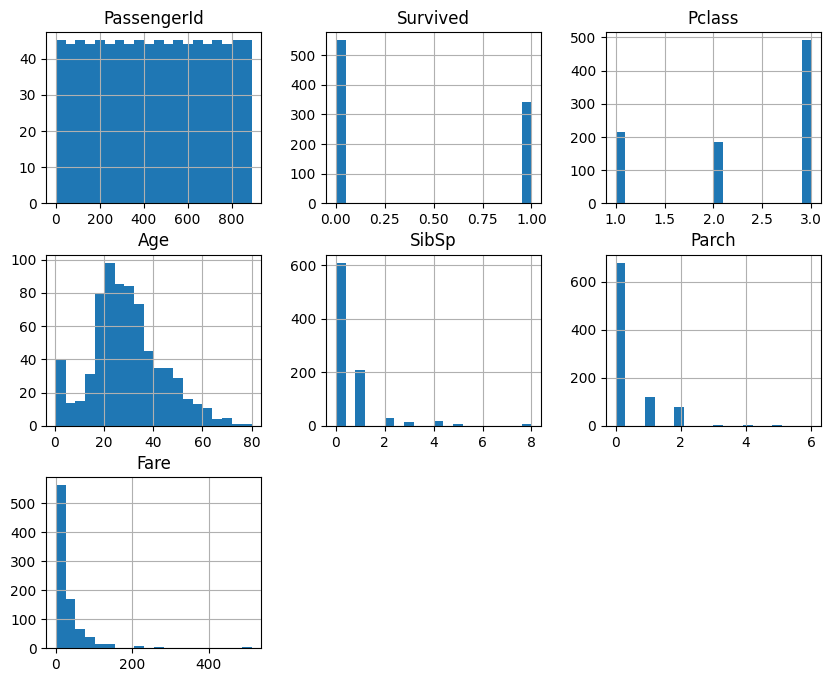

In [19]:
train.hist(bins=20, figsize=(10,8))
plt.show()

Need to Clean the data first, below I can see there is missing data, and non-numeric columns. The data transformation applied and learned on the training data must be applied to the testing data as well. I am using the standard scaler for the age and fare data as this give a more accurate representation of the distribution of fares a and wages which I expect to be normally distributed and thus will scale the data this way. I am using the onehotencoder for the sex data as to encode the sex to a number and not using the first column as to avoid the dummy problem when doing linear regression or the like. I may add back though if I do more non-linear models like random forest, decision trees etc. I want to look at the name and get the surname like mr., mrs, ms, rev, from the name. Can maybe extract some information out of the name, like first name, or maybe last name meant something more. The things to take into account about the people that survived are were they in a convient location to escape when the boat was going down so cabin may matter but all guest were scatterd. The class of people could have mattered as the lower class were maybe resticed to lower levels that were affected more by the water. Something else to consider is that maybe the fare paid which is correlated with socio-economic status as its possible rich people had a higher chance of surviving. The port left out of may play a part too, as possibly the richer people left out of a particular port more than others or were later to board so had worse cabin selection if the cabin only pointed to an area rather than a room. Worse cabin selection could mean worse position when the boat was sinking so more likely to die. The cabin number could also be correlated to what level of the boat they were one. I want to look at correlations between passenger ID and survived as maybe those that had higher ID's were more rich, if random should drop this column as only a primary key and means nothing. Were women and children favored, probably were. So age and sex will matter. Can look at the length of the string of the name and possibly this has some meaning to it, i.e. longer names means the people were more important and had titles. Look at correlation between socio-encomic status, fare, sibarch/parch to try and extropolate the cabin they were in. Maybe people who had bigger families, i.e. biggers rooms were in one area and if they have siblings or parents aboard could possibly mean they all stayed together so try and draw an inference that bigger families all stayed together and this area with big rooms was all close by so can give these people the same cabin, if nothing can be found could also look at if there is some sort of ticket mapping to each cabin. Want to transform the port embarked to some numerical number maybe to the % weight of how many people came fromt that port, so if S took up 70% of the people on the boat the s would be replaced with 70% instead of

In [6]:
train = pd.read_csv("C:/Users/golde/OneDrive/Desktop/Machine Learning/Titanic Kaggle Comp/Titantanic/Data/train.csv")

#The passthrough argument means that the rest of the columns keep as is, this method is similar to a pipeline, but for encoding/cleaning the data
#Can pass in tranformers in a list of list in [(name, the encoder, the colums),..., remainder=passthrough]
ct = ColumnTransformer(
    [("onehot",OneHotEncoder(drop="first",sparse_output=False),["Sex"]),
    ("stan_scale",StandardScaler(),["Age","Fare"])],
    remainder="passthrough")

#Sets the output to pandas dataframe to keep consistentcy
ct.set_output(transform="pandas")
train = ct.fit_transform(train)

test = pd.read_csv("C:/Users/golde/OneDrive/Desktop/Machine Learning/Titanic Kaggle Comp/Titantanic/Data/test.csv")

In [7]:
print(train)

     onehot__Sex_male  stan_scale__Age  stan_scale__Fare  \
0                 1.0        -0.530377         -0.502445   
1                 0.0         0.571831          0.786845   
2                 0.0        -0.254825         -0.488854   
3                 0.0         0.365167          0.420730   
4                 1.0         0.365167         -0.486337   
..                ...              ...               ...   
886               1.0        -0.185937         -0.386671   
887               0.0        -0.737041         -0.044381   
888               0.0              NaN         -0.176263   
889               1.0        -0.254825         -0.044381   
890               1.0         0.158503         -0.492378   

     remainder__PassengerId  remainder__Survived  remainder__Pclass  \
0                         1                    0                  3   
1                         2                    1                  1   
2                         3                    1                  

In [ ]:
print(train.shape)
print(train)

In [ ]:
print(test.shape)
print(test.dtypes)

Numeric columns


*   Integers: PassengerId, Pclass, SibSp, Parch
*   Float: Age, Fare

Non-numeric columns:


*   Name, Sex, Ticket, Cabin, Embarked

In [ ]:
train.describe()

In [ ]:
test.describe()